In [ ]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

# Explanatory Data Analysis

In [62]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')

df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]
# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df3 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df3.columns.difference(['child_weight'])
df3[cols_to_convert] = df3[cols_to_convert].astype(int)

df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


In [63]:
print(df3['malnurished'].value_counts())

malnurished
0    1985
1    1596
Name: count, dtype: int64


In [64]:
df3['child_age'].value_counts() # Child age is also categorical, not numerical

child_age
1    1269
2    1260
0    1052
Name: count, dtype: int64

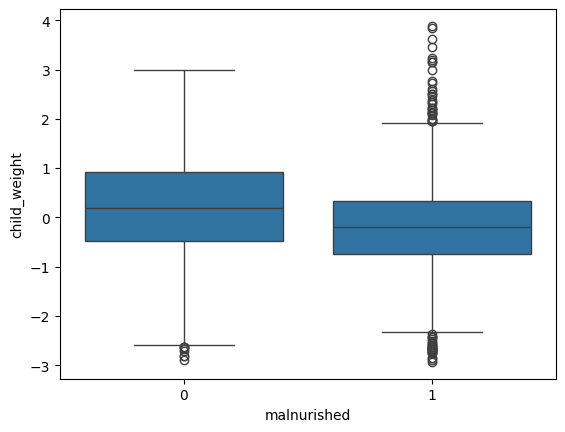

In [65]:
sns.boxplot(x='malnurished', y='child_weight',  data=df3)
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [66]:
# Listing all categorical features
cat_columns = ['child_age', 'ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'province', 'wealth_index']

# Contingency table for categorical features
contingency_tables = {}
for col in cat_columns:
    contingency_tables[col] = pd.crosstab(df2[col], df2['malnurished'])
    print(f"Contingency table for {col}:\n{contingency_tables[col]}\n")

Contingency table for child_age:
malnurished    0    1
child_age            
0.0          657  395
1.0          663  606
2.0          665  595

Contingency table for ever_breastfed:
malnurished        0     1
ever_breastfed            
0.0              142   116
1.0             1843  1480

Contingency table for diarrhoea_last_2_weeks:
malnurished                0     1
diarrhoea_last_2_weeks            
0.0                     1760  1385
1.0                      225   211

Contingency table for fever_last_2_weeks:
malnurished            0     1
fever_last_2_weeks            
0.0                 1515  1232
1.0                  470   364

Contingency table for area:
malnurished     0    1
area                  
0.0           826  787
1.0          1159  809

Contingency table for child_sex:
malnurished     0    1
child_sex             
0.0           978  684
1.0          1007  912

Contingency table for mother_education:
malnurished         0    1
mother_education          
0.0           

### $\chi^2$ Test

In [67]:
from scipy.stats import chi2_contingency

for col in cat_columns:
    contingency_table = contingency_tables[col]
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2: {chi2}, p-value: {p}, degrees of freedom: {dof}\n")

Chi-square test for child_age:
Chi2: 29.795079787417386, p-value: 3.3890707109508297e-07, degrees of freedom: 2

Chi-square test for ever_breastfed:
Chi2: 0.004451594233535216, p-value: 0.9468043983061583, degrees of freedom: 1

Chi-square test for diarrhoea_last_2_weeks:
Chi2: 2.767758691702098, p-value: 0.09618074892964458, degrees of freedom: 1

Chi-square test for fever_last_2_weeks:
Chi2: 0.32814973457000673, p-value: 0.5667506278904322, degrees of freedom: 1

Chi-square test for area:
Chi2: 20.872358977129554, p-value: 4.909279456427756e-06, degrees of freedom: 1

Chi-square test for child_sex:
Chi2: 14.369463371989564, p-value: 0.00015021877433952664, degrees of freedom: 1

Chi-square test for mother_education:
Chi2: 73.96393999831855, p-value: 3.2999851523459003e-15, degrees of freedom: 4

Chi-square test for health_insurance:
Chi2: 15.999267468650553, p-value: 6.336699714470311e-05, degrees of freedom: 1

Chi-square test for province:
Chi2: 126.7661408296377, p-value: 6.161697

### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [68]:
import numpy as np
cramers_v_results = {}

for col in cat_columns:
    if col != 'malnurished':
        table = pd.crosstab(df2[col], df2['malnurished'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        print(f"{col}: Cramér's V = {V:.4f}")



child_age: Cramér's V = 0.0912
ever_breastfed: Cramér's V = 0.0011
diarrhoea_last_2_weeks: Cramér's V = 0.0278
fever_last_2_weeks: Cramér's V = 0.0096
area: Cramér's V = 0.0763
child_sex: Cramér's V = 0.0633
mother_education: Cramér's V = 0.1437
health_insurance: Cramér's V = 0.0668
province: Cramér's V = 0.1881
wealth_index: Cramér's V = 0.1450


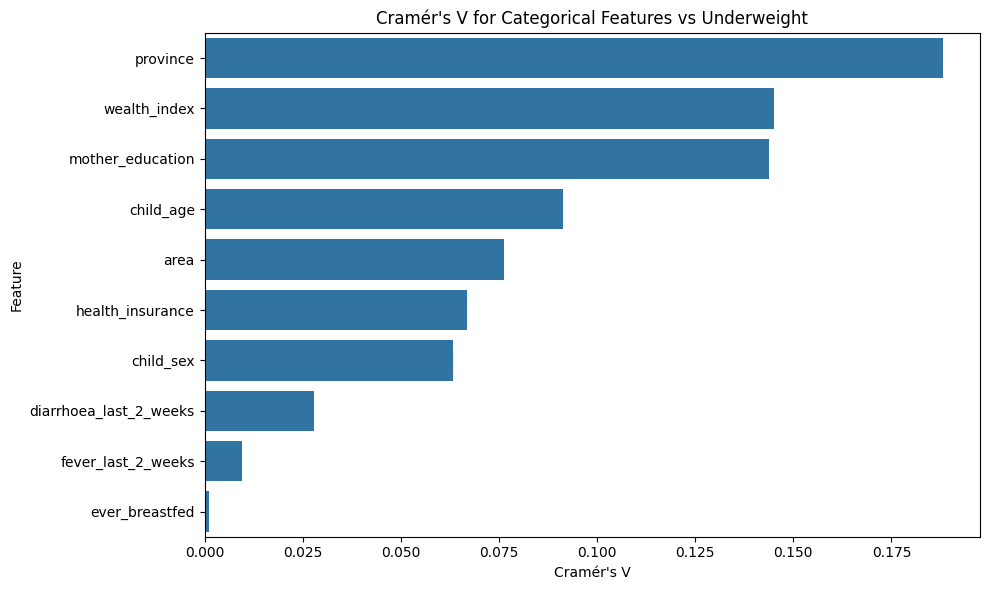

In [69]:
# Cramér's V values
cramers_v_df = pd.DataFrame.from_dict(cramers_v_results, orient='index', columns=['Cramér\'s V'])
cramers_v_df = cramers_v_df.sort_values(by='Cramér\'s V', ascending=False)
cramers_v_df.reset_index(inplace=True)
cramers_v_df.columns = ['Feature', 'Cramér\'s V']
# cramers_v_df.to_csv('/workspaces/malnutrition/MICS/cramers_v_results.csv', index=False)

# Plotting Cramér's V values
plt.figure(figsize=(10, 6))
sns.barplot(x='Cramér\'s V', y='Feature', data=cramers_v_df)
plt.title("Cramér's V for Categorical Features vs Underweight")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Train-test split

In [70]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)


# Logistic Regression

In [71]:
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
# print('Before SMOTE: ', Counter(y_train))
# print('After SMOTE: ', Counter(y_train_sm))

### Simple model

In [72]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       397
           1       0.71      0.65      0.68       320

    accuracy                           0.73       717
   macro avg       0.72      0.72      0.72       717
weighted avg       0.72      0.73      0.72       717



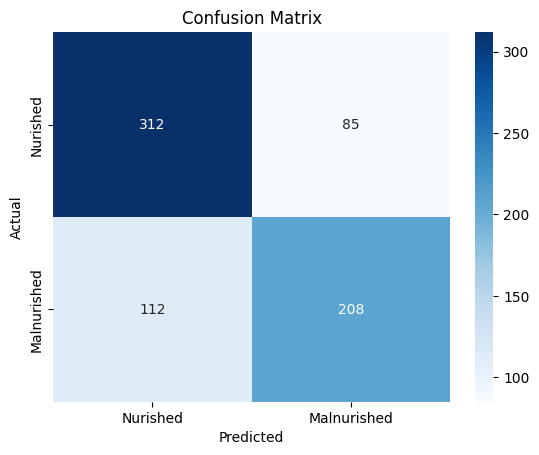

In [74]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
y_probas = model.predict_proba(X_test)[:, 1]

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.700560039212177


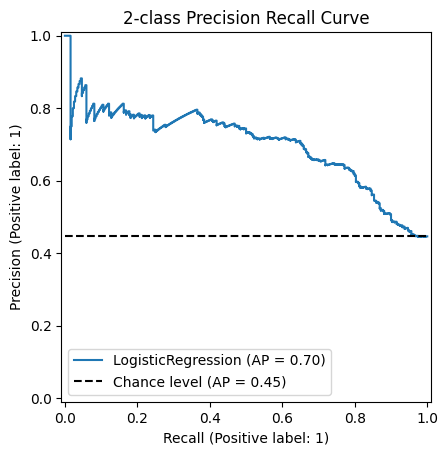

In [76]:
display = PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

---



# Prameter Tunned

In [90]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'class_weight': [None, 'balanced'],
        'l1_ratio': [0.1, 0.5, 0.9],  # required for elasticnet
        'max_iter': [100, 500, 1000]
    }
]


In [ ]:
log_reg = LogisticRegression(random_state=42)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    verbose=1,
    n_jobs=2
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 168 candidates, totalling 840 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"[{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [100, 500, ...], 'penalty': ['l2'], ...}, {'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [100, 500, ...], 'penalty': ['l1'], ...}, ...]"
,scoring,'recall'
,n_jobs,2
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [95]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.7092677696078431
Test Accuracy: 0.694560669456067
Confusion Matrix:
 [[271 126]
 [ 93 227]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.68      0.71       397
           1       0.64      0.71      0.67       320

    accuracy                           0.69       717
   macro avg       0.69      0.70      0.69       717
weighted avg       0.70      0.69      0.70       717



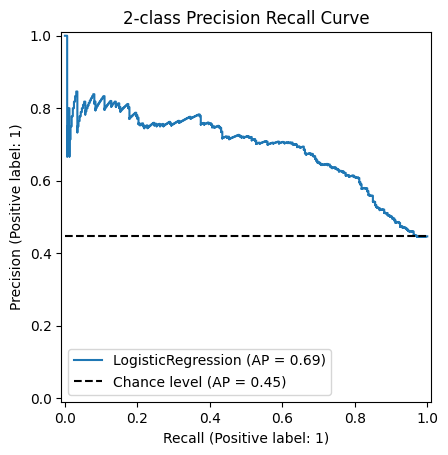

In [96]:
display = PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()